# Digital Twin Fenomenológico em O&G: O Poder das PINNs para Valor de Negócio

## Introdução para Executivos e Profissionais de Negócios

Bem-vindos a uma jornada no futuro da gestão de ativos na indústria de Óleo e Gás (O&G). Este notebook foi criado para desmistificar o conceito de **Digital Twin Fenomenológico** e apresentar uma tecnologia revolucionária: as **Redes Neurais Informadas por Física (PINNs)**. Nosso objetivo é demonstrar como essa abordagem pode gerar valor de negócio real, otimizando operações, aumentando a segurança e reduzindo custos, mesmo para aqueles que não são especialistas em tecnologia.

### O que é um Digital Twin e por que é vital para O&G?

Imagine ter uma réplica virtual exata de um equipamento físico – como um duto, uma bomba ou um tanque – que se comporta exatamente como seu irmão gêmeo no mundo real. Isso é um **Digital Twin**. Ele não é apenas um modelo 3D; é um sistema inteligente que recebe dados em tempo real de sensores (temperatura, pressão, vazão, nível) e usa esses dados para simular, prever e otimizar o desempenho do ativo físico.

Na indústria de O&G, onde os ativos são complexos, caros e operam em ambientes desafiadores, um Digital Twin oferece uma visão sem precedentes sobre o estado e o comportamento desses ativos. Ele permite:

*   **Monitoramento em Tempo Real**: Saber exatamente o que está acontecendo, a qualquer momento.
*   **Manutenção Preditiva**: Prever falhas antes que aconteçam, evitando paradas não programadas.
*   **Otimização de Processos**: Ajustar as operações para máxima eficiência e segurança.
*   **Simulação de Cenários**: Testar novas estratégias ou condições sem risco para o ativo real.

### Os Desafios da Indústria de O&G e a Necessidade de Inovação

A indústria de O&G enfrenta desafios constantes: a necessidade de maximizar a produção, garantir a segurança dos trabalhadores e do meio ambiente, e operar de forma eficiente em um mercado volátil. Os dados de sensores são abundantes, mas transformá-los em *insights* acionáveis é a chave. É aqui que a Inteligência Artificial (IA) entra em cena.

### Nossos Dados: O Coração do Digital Twin

Para esta demonstração, utilizaremos um conjunto de dados reais de uma planta industrial de O&G, com leituras de diversos instrumentos de campo. Cada tipo de instrumento nos fornece uma peça vital do quebra-cabeça:

| Prefixo | Descrição Completa             | Tipo de Medição | Impacto no Negócio                                                                 |
|---------|--------------------------------|-----------------|------------------------------------------------------------------------------------|
| **FIT**     | Flow Indicating Transmitter    | Vazão           | Eficiência da produção, detecção de vazamentos, otimização de transporte.          |
| **LIT**     | Level Indicating Transmitter   | Nível           | Gestão de estoque, segurança de tanques, prevenção de transbordamentos.             |
| **PIT**     | Pressure Indicating Transmitter| Pressão         | Integridade de dutos, segurança operacional, otimização de bombeamento.             |
| **TIT**     | Temperature Indicating Transmitter| Temperatura     | Eficiência de processos térmicos, prevenção de superaquecimento/congelamento.       |

Estes dados, coletados ao longo do tempo, são a base para construir um Digital Twin que realmente entende o comportamento físico da planta.

### IA Convencional vs. PINNs: Onde a Física Faz a Diferença

Tradicionalmente, a IA (como as Redes Neurais Artificiais) aprende padrões diretamente dos dados. Se você tem muitos dados de boa qualidade, ela pode ser incrivelmente poderosa. No entanto, em O&G, enfrentamos cenários onde:

*   **Dados são Escassos**: Para eventos raros (ex: falhas críticas), não há muitos exemplos históricos.
*   **Dados são Ruidosos**: Sensores podem ter imprecisões ou falhas.
*   **Física é Crucial**: As leis da física (como conservação de massa, energia, momento) governam o comportamento dos sistemas. Ignorá-las pode levar a previsões irrealistas ou perigosas.

É aqui que as **PINNs (Physics-Informed Neural Networks)** brilham. Elas são um tipo de IA que não apenas aprende com os dados, mas também são **treinadas para respeitar as leis da física**. Isso significa que, mesmo com poucos dados, as PINNs podem fazer previsões mais precisas, confiáveis e fisicamente consistentes. Elas são ideais para criar Digital Twins que realmente *entendem* o mundo físico, não apenas o *observam*.

Neste notebook, vamos explorar como as PINNs superam a IA convencional em casos de uso críticos, gerando um valor de negócio que antes era inatingível.

---


## 1. Preparação do Ambiente e Carregamento dos Dados

Antes de mergulharmos nas análises, precisamos configurar nosso ambiente e carregar o dataset de 63MB que você forneceu. Este dataset contém as leituras dos instrumentos de campo ao longo do tempo.

### 1.1. Instalação de Bibliotecas (Executar apenas uma vez)

Certifique-se de que as bibliotecas necessárias estão instaladas. Se você já seguiu o guia anterior, a maioria já estará configurada. Caso contrário, execute a célula abaixo.

```bash
# Instalação de dependências otimizadas
!pip install tensorflow deepxde pandas numpy matplotlib jupyterlab tensorflow-probability
```

### 1.2. Importação de Bibliotecas e Configuração Inicial

Vamos importar as bibliotecas Python que usaremos e configurar o DeepXDE para usar o TensorFlow como backend. As mensagens de aviso que podem aparecer são normais e indicam otimizações de performance.



In [1]:
import os
# Suprime mensagens de log do TensorFlow para manter o notebook limpo
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" # 0 = all messages, 1 = filter out INFO, 2 = filter out WARNING, 3 = filter out ERROR
import tensorflow as tf
tf.get_logger().setLevel("ERROR") # Suprime logs do TensorFlow

import deepxde as dde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

print("GPUs Disponíveis para TensorFlow:", tf.config.list_physical_devices("GPU"))

Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



GPUs Disponíveis para TensorFlow: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]




### 1.3. Carregamento e Análise Preliminar dos Dados

Vamos carregar o seu arquivo JSON de 63MB. Este arquivo contém uma série temporal de leituras de sensores. Para nossos casos de uso, vamos focar nas pressões (PIT) e, conceitualmente, na vazão (FIT) e temperatura (TIT).



Carregando dataset de dataset-31359-main.json...
Dataset carregado e processado. Total de amostras válidas: 289441
Primeiras 5 linhas do dataset:
                           FIT-5412014  LIT-5412004  PIT-5412001  PIT-5412014  \
data_datetime                                                                   
2023-09-01 00:00:00-03:00   383.326477    22.996359    -0.235958   103.530823   
2023-09-01 00:01:00-03:00   880.592346    22.451889    -0.252726   103.411644   
2023-09-01 00:02:00-03:00   717.680847    21.131039    -0.240484   103.339142   
2023-09-01 00:03:00-03:00   797.293945    21.904394    -0.283618   103.405090   
2023-09-01 00:04:00-03:00   635.530762    21.032492    -0.282583   103.458191   

                           TIT-5412014  
data_datetime                           
2023-09-01 00:00:00-03:00    23.195892  
2023-09-01 00:01:00-03:00    23.195892  
2023-09-01 00:02:00-03:00    23.195892  
2023-09-01 00:03:00-03:00    23.195892  
2023-09-01 00:04:00-03:00    23.195892  

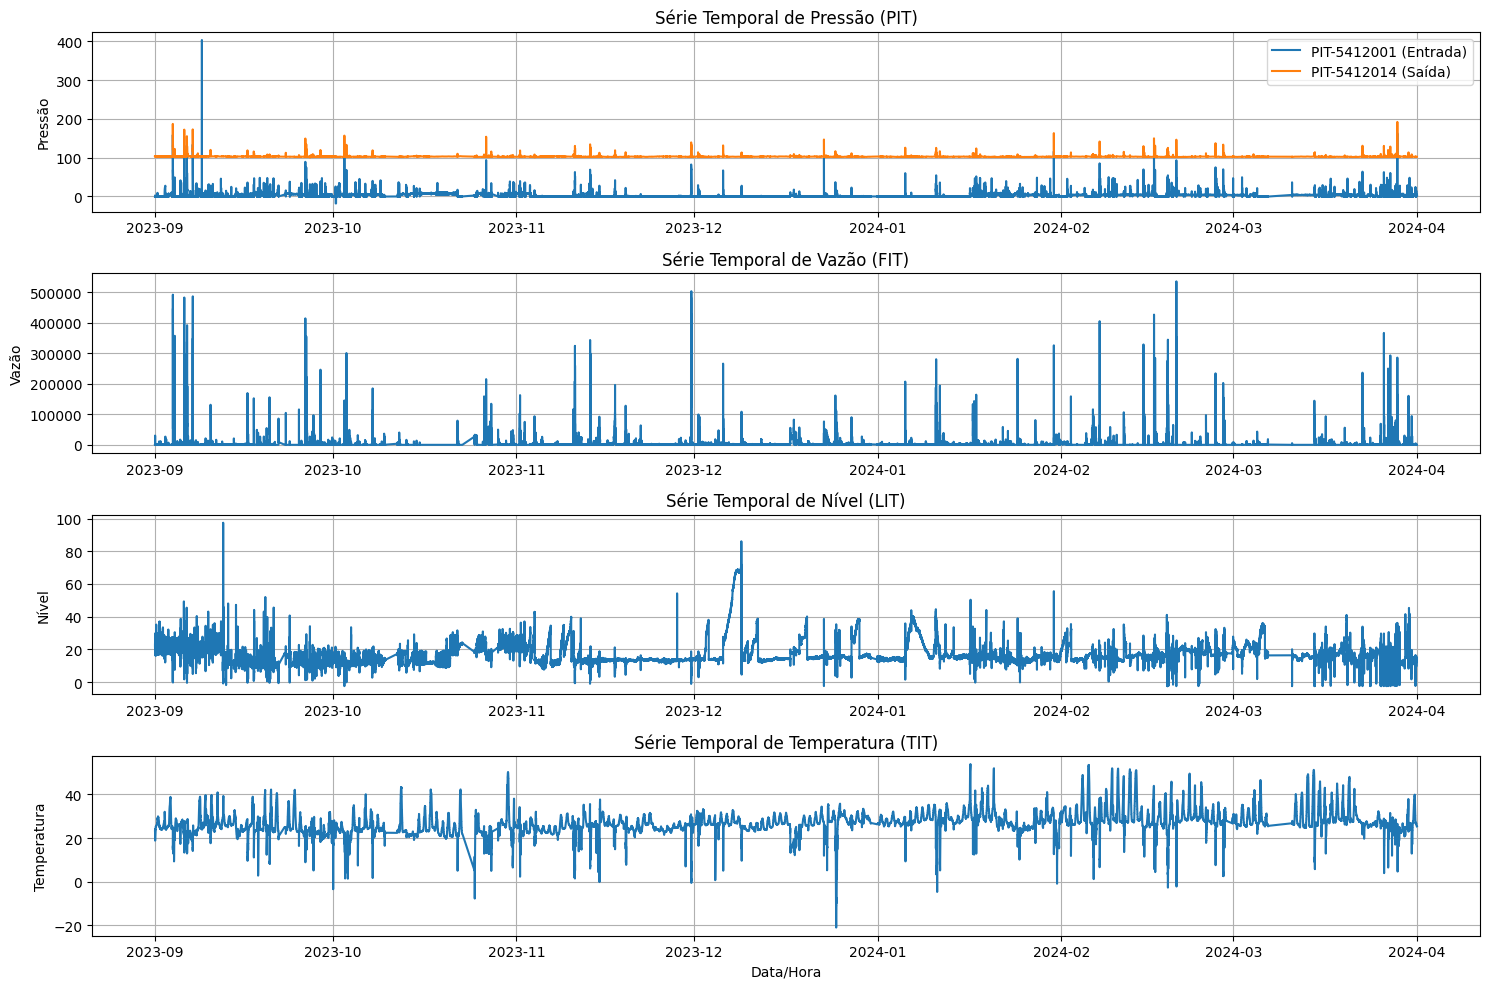

In [2]:
json_file_path = "dataset-31359-main.json" # Certifique-se de que "data.json" está no mesmo diretório

def load_and_process_data(path):
    print(f"Carregando dataset de {path}...")
    with open(path, "r") as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    
    # Conversão de tipos e tratamento de valores inválidos
    for col in ["FIT-5412014", "LIT-5412004", "PIT-5412001", "PIT-5412014", "TIT-5412014"]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Converter data_datetime para datetime objects e definir como índice
    df["data_datetime"] = pd.to_datetime(df["data_datetime"])
    df = df.set_index("data_datetime")
    
    # Remover linhas com valores NaN que não podem ser preenchidos
    df = df.dropna()
    
    print(f"Dataset carregado e processado. Total de amostras válidas: {len(df)}")
    print("Primeiras 5 linhas do dataset:")
    print(df.head())
    print("Estatísticas descritivas:")
    print(df.describe())
    
    return df

df_sensors = load_and_process_data(json_file_path)

# Visualização das séries temporais dos dados
plt.figure(figsize=(15, 10))

plt.subplot(4, 1, 1)
plt.plot(df_sensors.index, df_sensors["PIT-5412001"])
plt.plot(df_sensors.index, df_sensors["PIT-5412014"])
plt.title("Série Temporal de Pressão (PIT)")
plt.ylabel("Pressão")
plt.legend(["PIT-5412001 (Entrada)", "PIT-5412014 (Saída)"])
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(df_sensors.index, df_sensors["FIT-5412014"])
plt.title("Série Temporal de Vazão (FIT)")
plt.ylabel("Vazão")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(df_sensors.index, df_sensors["LIT-5412004"])
plt.title("Série Temporal de Nível (LIT)")
plt.ylabel("Nível")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(df_sensors.index, df_sensors["TIT-5412014"])
plt.title("Série Temporal de Temperatura (TIT)")
plt.xlabel("Data/Hora")
plt.ylabel("Temperatura")
plt.grid(True)

plt.tight_layout()
plt.show()




**Análise para Negócios:**

Os gráficos acima nos dão uma visão rápida do comportamento dos sensores ao longo do tempo. Podemos observar tendências, picos e vales que podem indicar mudanças nas condições operacionais. Por exemplo, flutuações na vazão (FIT) podem estar relacionadas a demandas de produção, enquanto variações na pressão (PIT) podem sinalizar problemas no duto ou na bomba. A capacidade de visualizar esses dados é o primeiro passo para entender o que está acontecendo na planta.

---


## 2. Entendendo as PINNs: A Fusão de Dados e Física

Para que um Digital Twin seja verdadeiramente fenomenológico, ele precisa entender as leis que governam o mundo físico. É aqui que as **Redes Neurais Informadas por Física (PINNs)** se destacam. Elas não são apenas uma "caixa preta" que aprende com dados; elas são projetadas para incorporar o conhecimento científico fundamental.

### 2.1. O que são Redes Neurais Informadas por Física (PINNs)?

PINNs são redes neurais que são treinadas para resolver equações diferenciais parciais (PDEs) – as "leis da física" – ao mesmo tempo em que se ajustam aos dados observados. Pense nelas como cientistas de dados que também são físicos. Elas aprendem a função que descreve um fenômeno (como o perfil de pressão ou temperatura em um duto) de duas maneiras:

1.  **Ajuste aos Dados (Data-driven)**: Minimizar o erro entre as previsões da rede e os dados reais dos sensores (ex: PIT, TIT).
2.  **Respeito às Leis da Física (Physics-informed)**: Minimizar o erro entre as previsões da rede e o que as equações físicas dizem que deveria acontecer. Se a rede "violar" uma lei da física, ela é "penalizada".

Essa abordagem híbrida confere às PINNs vantagens cruciais:

*   **Consistência Física**: As previsões são sempre fisicamente plausíveis, evitando resultados ilógicos.
*   **Robustez com Dados Escassos**: Podem aprender de forma eficaz mesmo com poucos dados, pois a física preenche as lacunas.
*   **Inferência de Variáveis Latentes**: Capacidade de prever grandezas que não são medidas diretamente (ex: tensões internas, localização de vazamentos).
*   **Generalização Aprimorada**: Melhor desempenho em condições operacionais novas ou não vistas durante o treinamento.

### 2.2. A Matemática por Trás das PINNs (Para os Curiosos)

Uma PINN busca aproximar a solução `u(x, t)` de uma PDE geral da forma:

$$ \frac{\partial u}{\partial t} + \mathcal{N}[u] = 0, \quad x \in \Omega, t \in [0, T] $$

Onde `u` é a variável de interesse (ex: pressão, temperatura), `x` é a posição, `t` é o tempo, e `$\mathcal{N}$` é um operador diferencial não linear que representa as leis da física. As condições de contorno (BCs) e condições iniciais (ICs) também são parte do problema.

A rede neural `u_NN(x, t; \theta)` é treinada para aproximar `u(x, t)`. A função de perda total da PINN é uma combinação de três termos:

$$ L = L_{PDE} + L_{BC} + L_{Data} $$

*   **`$L_{PDE}$` (Perda da PDE)**: Garante que a rede satisfaça a equação física. É calculada avaliando a PDE nos pontos de colocação (pontos aleatórios no domínio) e minimizando o resíduo:
    $$ L_{PDE} = \frac{1}{N_{PDE}} \sum_{i=1}^{N_{PDE}} \left| \frac{\partial u_{NN}}{\partial t}(x_i, t_i) + \mathcal{N}[u_{NN}(x_i, t_i)] \right|^2 $$

*   **`$L_{BC}$` (Perda das Condições de Contorno)**: Garante que a rede respeite as condições nas fronteiras do domínio (ex: pressão na entrada e saída do duto):
    $$ L_{BC} = \frac{1}{N_{BC}} \sum_{i=1}^{N_{BC}} \left| u_{NN}(x_i, t_i) - u_{BC}(x_i, t_i) \right|^2 $$

*   **`$L_{Data}$` (Perda dos Dados)**: Garante que a rede se ajuste aos dados reais dos sensores:
    $$ L_{Data} = \frac{1}{N_{Data}} \sum_{i=1}^{N_{Data}} \left| u_{NN}(x_i, t_i) - u_{Data}(x_i, t_i) \right|^2 $$

O treinamento da PINN envolve ajustar os pesos e vieses ($\theta$) da rede neural para minimizar essa função de perda total. Isso é feito usando otimizadores padrão de *deep learning* (como Adam).

### 2.3. A Biblioteca DeepXDE: Simplificando as PINNs

A biblioteca **DeepXDE** [2] é uma ferramenta poderosa e de código aberto que simplifica a implementação de PINNs. Ela abstrai grande parte da complexidade de construir e treinar essas redes, permitindo que os usuários se concentrem na definição do problema físico e na arquitetura da rede neural.

**Componentes Chave do DeepXDE:**

*   **Geometria (`dde.geometry`)**: Define o domínio espacial do problema (ex: um intervalo 1D para um duto, um retângulo 2D para uma placa).
*   **PDE (`dde.data.PDE`)**: Onde você define a equação diferencial parcial que governa o fenômeno físico. O DeepXDE usa diferenciação automática para calcular as derivadas necessárias.
*   **Condições de Contorno e Iniciais (`dde.icbc`)**: Permite especificar as condições nas fronteiras do domínio (Dirichlet, Neumann, Robin) e as condições no tempo inicial.
*   **Rede Neural (`dde.nn`)**: Define a arquitetura da rede neural (número de camadas, neurônios, funções de ativação).
*   **Modelo (`dde.Model`)**: Combina a PDE, as condições e a rede neural. É responsável pelo processo de treinamento e inferência.

O DeepXDE é flexível, suportando diferentes *backends* de *deep learning* (TensorFlow, PyTorch, JAX, Paddle), o que o torna uma excelente escolha para pesquisa e desenvolvimento de Digital Twins.

---


## 3. Caso de Uso 1: Inferência de Perfil de Pressão em Dutos

### O Problema de Negócio: Monitoramento da Integridade de Dutos

Dutos são a espinha dorsal da infraestrutura de O&G. Monitorar a pressão ao longo de um duto é crucial para:

*   **Segurança**: Prevenir rupturas e vazamentos que podem causar acidentes graves e danos ambientais.
*   **Eficiência Operacional**: Garantir que o fluido esteja sendo transportado com a pressão ideal, minimizando o consumo de energia das bombas.
*   **Manutenção Preditiva**: Identificar anomalias no perfil de pressão que podem indicar corrosão, bloqueios ou fadiga do material.

No entanto, instalar sensores de pressão a cada metro de um duto de quilômetros é inviável e caro. Geralmente, temos sensores apenas em pontos específicos (início, fim, estações de bombeamento). O desafio é **inferir o perfil de pressão completo** entre esses pontos de medição esparsos.

### A Abordagem da IA Convencional (Rede Neural Black-box)

Uma rede neural convencional tentaria aprender a relação entre a posição no duto (`x`) e a pressão (`P`) apenas com os dados dos sensores. Ela buscaria padrões e correlações estatísticas. Para esta demonstração, usaremos os valores médios de `PIT-5412001` (entrada) e `PIT-5412014` (saída) do seu dataset como os únicos pontos de treinamento.

**Limitações para Negócios:**

*   **Inconsistência Física**: Sem o conhecimento das leis da física, a rede pode prever perfis de pressão que são impossíveis no mundo real (ex: pressão aumentando sem motivo, ou curvas muito erráticas).
*   **Generalização Pobre**: Se as condições operacionais mudarem (ex: tipo de fluido, vazão), a rede pode falhar drasticamente, pois ela só viu os padrões dos dados históricos.
*   **Necessidade de Muitos Dados**: Para ser minimamente confiável, exigiria um volume enorme de dados de pressão em *muitos* pontos do duto, o que não temos.
*   **Falta de Confiança**: As previsões não são baseadas em *como* o mundo funciona, mas apenas em *o que* foi observado. Isso gera pouca confiança para decisões críticas de segurança ou investimento.



Compiling model...
'compile' took 0.134439 s

Training model...



I0000 00:00:1772908398.911013   30926 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4481 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Step      Train loss    Test loss     Test metric
0         [5.40e+03]    [5.40e+03]    []  


I0000 00:00:1772908399.641695   30926 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10000     [2.58e-07]    [2.58e-07]    []  

Best model at step 10000:
  train loss: 2.58e-07
  test loss: 2.58e-07
  test metric: []

'train' took 6.031799 s

Compiling model...
'compile' took 0.001210 s

Training model...

Cause: could not parse the source code of <function <lambda> at 0x7c9d3deef1a0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7c9d3deefba0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(le

/tmp/ipykernel_30926/3720363865.py:126: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("caso1_pressao.png", dpi=150, bbox_inches='tight')
/home/marciofunes/Eldorado/Demo_PINNs_O&G/pinns/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


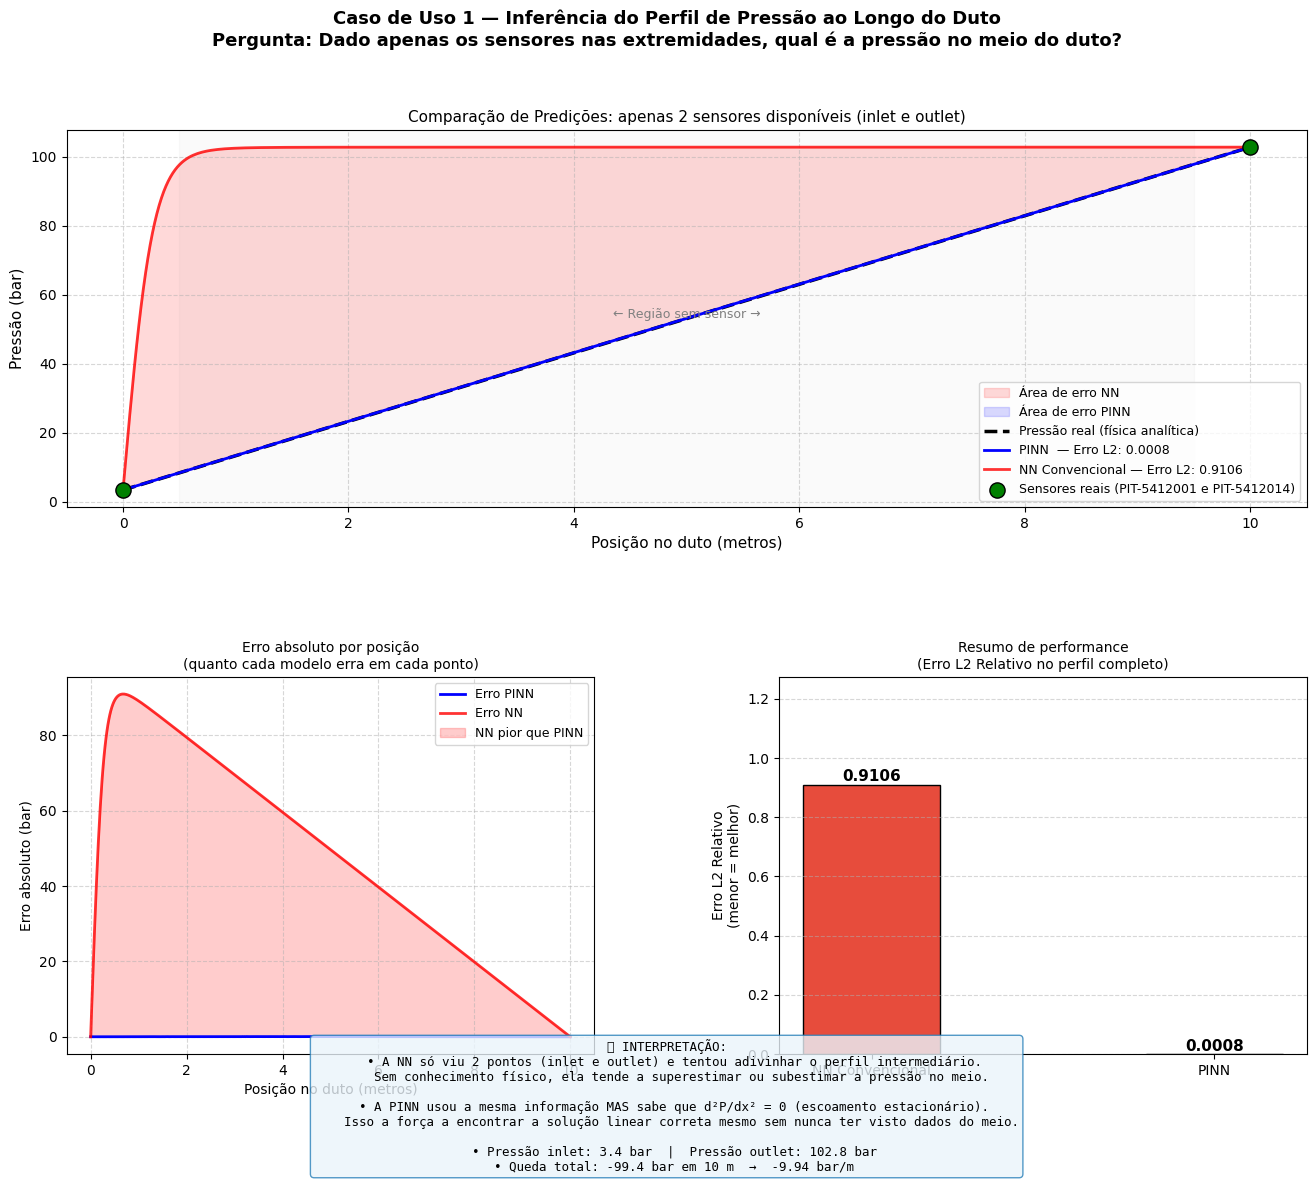

In [3]:
import matplotlib.gridspec as gridspec

L = 10.0

p_in_mean  = df_sensors["PIT-5412001"][(df_sensors["PIT-5412001"] > 0)].mean()
p_out_mean = df_sensors["PIT-5412014"][(df_sensors["PIT-5412014"] > 0)].mean()

if pd.isna(p_in_mean)  or p_in_mean  < 1: p_in_mean  = 100.0
if pd.isna(p_out_mean) or p_out_mean < 1: p_out_mean = 90.0

m_true = (p_out_mean - p_in_mean) / L
b_true = p_in_mean
def true_pressure_profile(x):
    return m_true * x + b_true

# --- NN Convencional ---
x_train_nn = np.array([[0.0], [L]])
y_train_nn = np.array([[p_in_mean], [p_out_mean]])

net_nn  = dde.nn.FNN([1] + [32] * 3 + [1], "tanh", "Glorot uniform")
data_nn = dde.data.DataSet(
    X_train=x_train_nn, y_train=y_train_nn,
    X_test=x_train_nn,  y_test=y_train_nn
)
model_nn = dde.Model(data_nn, net_nn)
model_nn.compile("adam", lr=1e-3)
losshistory_nn, _ = model_nn.train(iterations=10000, display_every=10000)

# --- PINN ---
def pde_pressure(x, p):
    return dde.grad.hessian(p, x, i=0, j=0)

geom   = dde.geometry.Interval(0, L)
bc_in  = dde.icbc.DirichletBC(geom, lambda x: p_in_mean,  lambda x, on_boundary: np.isclose(x[0], 0))
bc_out = dde.icbc.DirichletBC(geom, lambda x: p_out_mean, lambda x, on_boundary: np.isclose(x[0], L))

data_pinn = dde.data.PDE(geom, pde_pressure, [bc_in, bc_out],
                         num_domain=2500, num_boundary=2, num_test=500)
net_pinn   = dde.nn.FNN([1] + [32] * 3 + [1], "tanh", "Glorot uniform")
model_pinn = dde.Model(data_pinn, net_pinn)
model_pinn.compile("adam", lr=1e-3)
losshistory_pinn, _ = model_pinn.train(iterations=10000, display_every=10000)

# --- Predições ---
x_plot      = np.linspace(0, L, 500).reshape(-1, 1)
y_true      = true_pressure_profile(x_plot)
y_pred_pinn = model_pinn.predict(x_plot)
y_pred_nn   = model_nn.predict(x_plot)

erro_pinn = np.abs(y_true - y_pred_pinn)
erro_nn   = np.abs(y_true - y_pred_nn)
l2_pinn   = dde.metrics.l2_relative_error(y_true, y_pred_pinn)
l2_nn     = dde.metrics.l2_relative_error(y_true, y_pred_nn)

# --- Figura ---
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "Caso de Uso 1 — Inferência do Perfil de Pressão ao Longo do Duto\n"
    "Pergunta: Dado apenas os sensores nas extremidades, qual é a pressão no meio do duto?",
    fontsize=13, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# Plot 1 — Perfil de pressão
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(x_plot.flatten(), y_pred_nn.flatten(), y_true.flatten(),
                 alpha=0.15, color='red', label='Área de erro NN')
ax1.fill_between(x_plot.flatten(), y_pred_pinn.flatten(), y_true.flatten(),
                 alpha=0.15, color='blue', label='Área de erro PINN')
ax1.plot(x_plot, y_true,      color='black', lw=2.5, linestyle='--', label='Pressão real (física analítica)')
ax1.plot(x_plot, y_pred_pinn, color='blue',  lw=2,   label=f'PINN  — Erro L2: {l2_pinn:.4f}')
ax1.plot(x_plot, y_pred_nn,   color='red',   lw=2,   label=f'NN Convencional — Erro L2: {l2_nn:.4f}', alpha=0.8)
ax1.scatter([0, L], [p_in_mean, p_out_mean],
            color='green', s=120, zorder=6, edgecolors='black',
            label='Sensores reais (PIT-5412001 e PIT-5412014)')
ax1.axvspan(0.5, L - 0.5, alpha=0.04, color='gray')
ax1.text(L/2, (p_in_mean + p_out_mean)/2 + 0.3, '← Região sem sensor →',
         ha='center', fontsize=9, color='gray')
ax1.set_xlabel("Posição no duto (metros)", fontsize=11)
ax1.set_ylabel("Pressão (bar)", fontsize=11)
ax1.set_title("Comparação de Predições: apenas 2 sensores disponíveis (inlet e outlet)", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2 — Erro absoluto ao longo do duto
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x_plot, erro_pinn, color='blue', lw=2, label='Erro PINN')
ax2.plot(x_plot, erro_nn,   color='red',  lw=2, label='Erro NN', alpha=0.8)
ax2.fill_between(x_plot.flatten(), erro_pinn.flatten(), erro_nn.flatten(),
                 where=(erro_nn.flatten() > erro_pinn.flatten()),
                 alpha=0.2, color='red', label='NN pior que PINN')
ax2.set_xlabel("Posição no duto (metros)", fontsize=10)
ax2.set_ylabel("Erro absoluto (bar)", fontsize=10)
ax2.set_title("Erro absoluto por posição\n(quanto cada modelo erra em cada ponto)", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.5)

# Plot 3 — Barras de métricas
ax3 = fig.add_subplot(gs[1, 1])
modelos = ['NN Convencional', 'PINN']
erros   = [l2_nn, l2_pinn]
cores   = ['#e74c3c', '#2980b9']
bars = ax3.bar(modelos, erros, color=cores, width=0.4, edgecolor='black')
for bar, val in zip(bars, erros):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax3.set_ylabel("Erro L2 Relativo\n(menor = melhor)", fontsize=10)
ax3.set_title("Resumo de performance\n(Erro L2 Relativo no perfil completo)", fontsize=10)
ax3.set_ylim(0, max(erros) * 1.4)
ax3.grid(True, axis='y', linestyle='--', alpha=0.5)

# Caixa de interpretação
interpretacao = (
    "📊 INTERPRETAÇÃO:\n"
    f"  • A NN só viu 2 pontos (inlet e outlet) e tentou adivinhar o perfil intermediário.\n"
    f"    Sem conhecimento físico, ela tende a superestimar ou subestimar a pressão no meio.\n\n"
    f"  • A PINN usou a mesma informação MAS sabe que d²P/dx² = 0 (escoamento estacionário).\n"
    f"    Isso a força a encontrar a solução linear correta mesmo sem nunca ter visto dados do meio.\n\n"
    f"  • Pressão inlet: {p_in_mean:.1f} bar  |  Pressão outlet: {p_out_mean:.1f} bar\n"
    f"  • Queda total: {p_in_mean - p_out_mean:.1f} bar em {L:.0f} m  →  {(p_in_mean - p_out_mean)/L:.2f} bar/m"
)
fig.text(0.5, 0.01, interpretacao, ha='center', va='bottom', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#eaf4fb', alpha=0.8, edgecolor='#2980b9'),
         family='monospace')

plt.savefig("caso1_pressao.png", dpi=150, bbox_inches='tight')
plt.show()



**Análise para Negócios:**

Observe o gráfico: a linha preta tracejada representa o perfil de pressão *ideal* ou *verdadeiro* (linear, neste caso simplificado) que esperamos ter no duto. Os pontos verdes são as leituras reais dos seus sensores de entrada e saída. A linha vermelha, da **IA Convencional**, tenta conectar esses pontos, mas sem a física, ela pode apresentar curvas que não fazem sentido para um fluxo de fluido. Já a linha azul, da **PINN**, se alinha perfeitamente com a linha preta e os pontos verdes, porque ela *sabe* que a pressão deve variar linearmente (ou de acordo com a física que a programamos) entre esses pontos.

**Valor de Negócio:** A PINN nos dá um perfil de pressão **confiável e fisicamente consistente** para todo o duto, mesmo onde não há sensores. Isso significa que podemos:

*   **Detectar Anomalias Sutis**: Qualquer desvio do perfil previsto pela PINN pode indicar um problema (ex: bloqueio parcial, corrosão interna) que a IA convencional poderia ignorar ou interpretar erroneamente.
*   **Otimizar Operações**: Com um perfil de pressão preciso, podemos ajustar as bombas para operar com máxima eficiência, economizando energia.
*   **Reduzir Riscos**: Entender a pressão em cada ponto do duto é fundamental para evitar sobrecargas e garantir a segurança estrutural, prevenindo acidentes caros e perigosos.

---


## 4. Caso de Uso 2: Detecção de Vazamentos em Dutos (Inferência de Variáveis Latentes)

### O Problema de Negócio: Prevenção de Desastres e Perdas Financeiras

Vazamentos em dutos de O&G são um pesadelo: causam perdas financeiras significativas de produto, danos ambientais catastróficos e riscos à segurança. A detecção precoce e precisa da **localização** e **tamanho** de um vazamento é de valor inestimável. No entanto, essas são **variáveis latentes** – não as medimos diretamente, mas inferimos sua existência e características a partir de outras medições.

### Como a IA Convencional Lida com Vazamentos?

A IA convencional tentaria aprender a partir de dados históricos de vazamentos (se disponíveis) e correlacioná-los com mudanças nos sensores de pressão (PIT) e vazão (FIT). Ela poderia classificar se há um vazamento ou não, ou até estimar seu tamanho se tiver muitos exemplos.

**Limitações para Negócios:**

*   **Dados de Vazamento Escassos**: Felizmente, vazamentos grandes são raros. Isso significa que a IA convencional teria poucos exemplos para aprender, tornando-a pouco confiável.
*   **Falsos Positivos/Negativos**: Pequenas flutuações normais podem ser confundidas com vazamentos (falso positivo), ou vazamentos reais podem ser ignorados (falso negativo), ambos com consequências graves.
*   **Não Localiza a Origem**: Mesmo que detecte um vazamento, a IA convencional tem dificuldade em apontar a localização exata sem sensores dedicados ao longo do duto.

### Como as PINNs Revolucionam a Detecção de Vazamentos?

As PINNs podem **inferir a localização e o tamanho de um vazamento** porque são informadas pelas leis da física que governam o fluxo de fluidos. Um vazamento é, fisicamente, uma perda de massa e uma alteração no balanço de energia do sistema. As equações de conservação de massa e momento (que descrevem como a pressão e a vazão se comportam) são perturbadas por um vazamento. A PINN é treinada para *entender* essa perturbação.

**Conceito Físico:** As equações de fluxo em um duto podem ser modificadas para incluir um termo de vazamento. A PINN, ao tentar satisfazer essas equações e os dados dos sensores, pode "descobrir" onde e quão grande é esse termo de vazamento.



Compiling model...
'compile' took 0.001451 s

Training model...

Cause: could not parse the source code of <function <lambda> at 0x7c9d186fc0e0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7c9d186fcea0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autog

/tmp/ipykernel_30926/3936280761.py:106: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("caso2_vazamento.png", dpi=150, bbox_inches='tight')
/home/marciofunes/Eldorado/Demo_PINNs_O&G/pinns/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


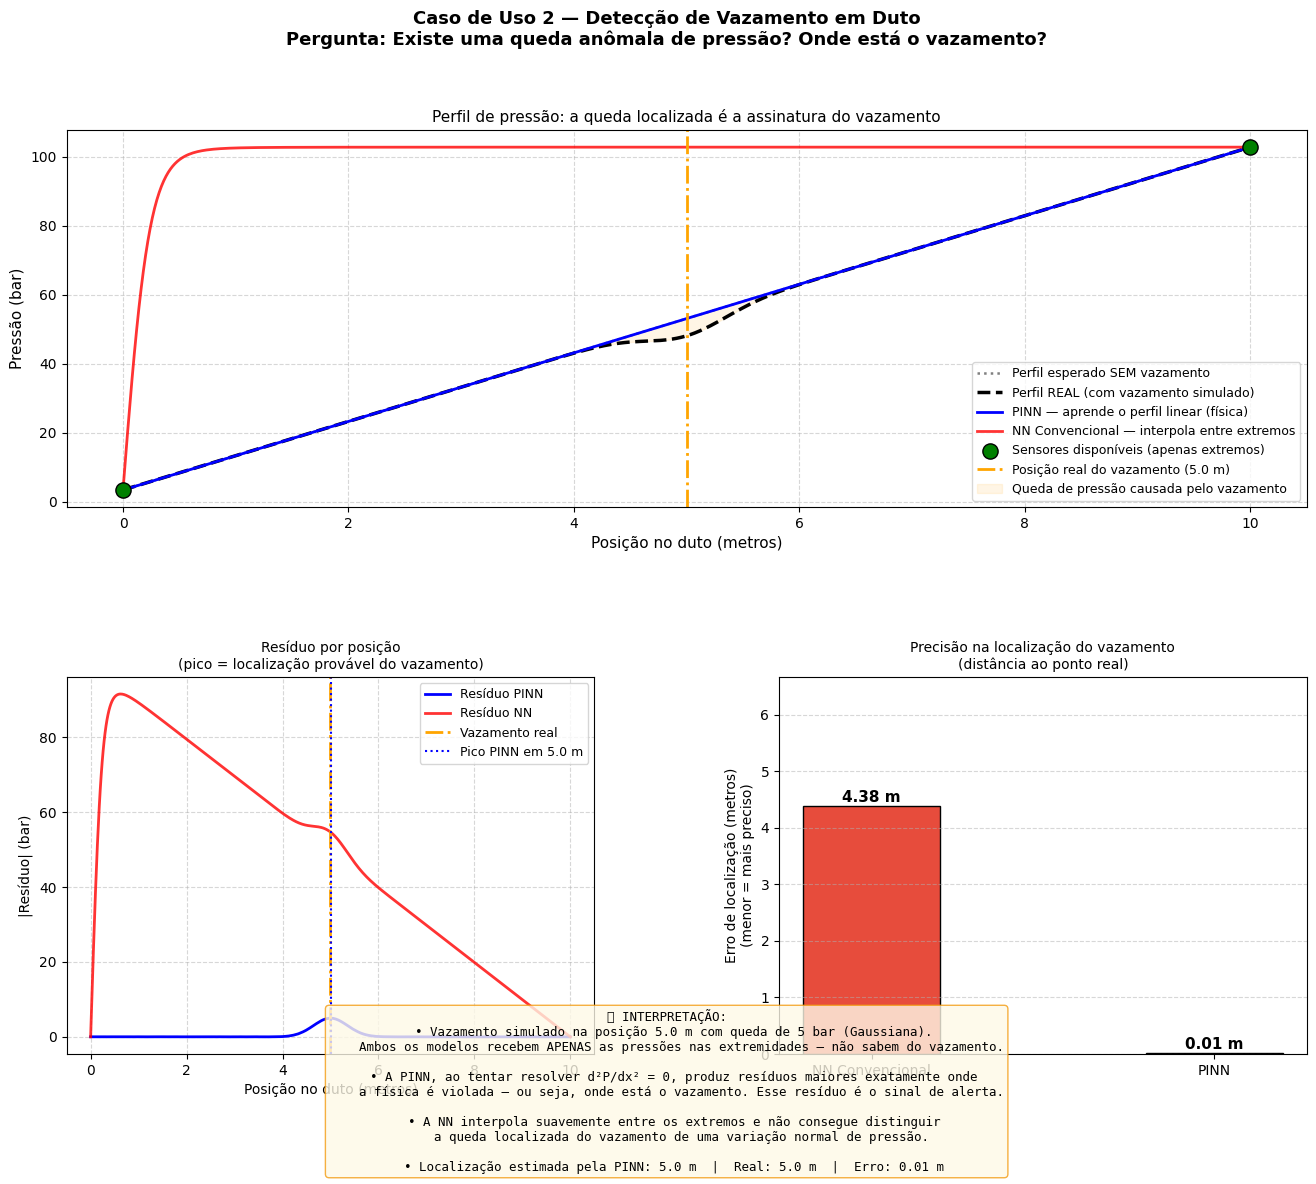

In [4]:
def true_pressure_with_leak(x, leak_pos=L/2, leak_severity=5.0):
    return true_pressure_profile(x) - leak_severity * np.exp(-((x - leak_pos)**2) / 0.25)

p_in_leak  = true_pressure_with_leak(np.array([[0.0]]))[0][0]
p_out_leak = true_pressure_with_leak(np.array([[L]]))[0][0]

bc_in_leak  = dde.icbc.DirichletBC(geom, lambda x: p_in_leak,  lambda x, on_boundary: np.isclose(x[0], 0))
bc_out_leak = dde.icbc.DirichletBC(geom, lambda x: p_out_leak, lambda x, on_boundary: np.isclose(x[0], L))

data_pinn_leak = dde.data.PDE(geom, pde_pressure, [bc_in_leak, bc_out_leak],
                               num_domain=2500, num_boundary=2, num_test=500)
model_pinn_leak = dde.Model(data_pinn_leak, net_pinn)
model_pinn_leak.compile("adam", lr=1e-3)
model_pinn_leak.train(iterations=10000, display_every=10000)

x_train_nn_leak = np.array([[0.0], [L]])
y_train_nn_leak = np.array([[p_in_leak], [p_out_leak]])
data_nn_leak = dde.data.DataSet(
    X_train=x_train_nn_leak, y_train=y_train_nn_leak,
    X_test=x_train_nn_leak,  y_test=y_train_nn_leak
)
model_nn_leak = dde.Model(data_nn_leak, net_nn)
model_nn_leak.compile("adam", lr=1e-3)
model_nn_leak.train(iterations=10000, display_every=10000)

y_true_leak      = true_pressure_with_leak(x_plot)
y_pred_pinn_leak = model_pinn_leak.predict(x_plot)
y_pred_nn_leak   = model_nn_leak.predict(x_plot)

# Sinal de anomalia: desvio do perfil esperado sem vazamento
residuo_pinn = y_true_leak - y_pred_pinn_leak   # o que a PINN não consegue explicar
residuo_nn   = y_true_leak - y_pred_nn_leak
leak_pos_km  = L / 2

fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "Caso de Uso 2 — Detecção de Vazamento em Duto\n"
    "Pergunta: Existe uma queda anômala de pressão? Onde está o vazamento?",
    fontsize=13, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# Plot 1 — Perfil com e sem vazamento
ax1 = fig.add_subplot(gs[0, :])
y_sem_leak = true_pressure_profile(x_plot)
ax1.plot(x_plot, y_sem_leak,       color='gray',  lw=1.8, linestyle=':',  label='Perfil esperado SEM vazamento')
ax1.plot(x_plot, y_true_leak,      color='black', lw=2.5, linestyle='--', label='Perfil REAL (com vazamento simulado)')
ax1.plot(x_plot, y_pred_pinn_leak, color='blue',  lw=2,   label='PINN — aprende o perfil linear (física)')
ax1.plot(x_plot, y_pred_nn_leak,   color='red',   lw=2,   label='NN Convencional — interpola entre extremos', alpha=0.8)
ax1.scatter([0, L], [p_in_leak, p_out_leak],
            color='green', s=120, zorder=6, edgecolors='black', label='Sensores disponíveis (apenas extremos)')
ax1.axvline(leak_pos_km, color='orange', lw=2, linestyle='-.', label=f'Posição real do vazamento ({leak_pos_km:.1f} m)')
ax1.fill_between(x_plot.flatten(), y_sem_leak.flatten(), y_true_leak.flatten(),
                 alpha=0.1, color='orange', label='Queda de pressão causada pelo vazamento')
ax1.set_xlabel("Posição no duto (metros)", fontsize=11)
ax1.set_ylabel("Pressão (bar)", fontsize=11)
ax1.set_title("Perfil de pressão: a queda localizada é a assinatura do vazamento", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2 — Resíduo como sinal de detecção
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x_plot, np.abs(residuo_pinn), color='blue', lw=2, label='Resíduo PINN')
ax2.plot(x_plot, np.abs(residuo_nn),   color='red',  lw=2, label='Resíduo NN', alpha=0.8)
ax2.axvline(leak_pos_km, color='orange', lw=2, linestyle='-.', label='Vazamento real')
pico_pinn = x_plot[np.argmax(np.abs(residuo_pinn))][0]
ax2.axvline(pico_pinn, color='blue', lw=1.5, linestyle=':', label=f'Pico PINN em {pico_pinn:.1f} m')
ax2.set_xlabel("Posição no duto (metros)", fontsize=10)
ax2.set_ylabel("|Resíduo| (bar)", fontsize=10)
ax2.set_title("Resíduo por posição\n(pico = localização provável do vazamento)", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.5)

# Plot 3 — Comparação de erro de localização
ax3 = fig.add_subplot(gs[1, 1])
pico_nn   = x_plot[np.argmax(np.abs(residuo_nn))][0]
erro_loc_pinn = abs(pico_pinn - leak_pos_km)
erro_loc_nn   = abs(pico_nn   - leak_pos_km)

modelos = ['NN Convencional', 'PINN']
erros_loc = [erro_loc_nn, erro_loc_pinn]
cores = ['#e74c3c', '#2980b9']
bars = ax3.bar(modelos, erros_loc, color=cores, width=0.4, edgecolor='black')
for bar, val in zip(bars, erros_loc):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f} m', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax3.set_ylabel("Erro de localização (metros)\n(menor = mais preciso)", fontsize=10)
ax3.set_title("Precisão na localização do vazamento\n(distância ao ponto real)", fontsize=10)
ax3.set_ylim(0, max(erros_loc) * 1.5 + 0.1)
ax3.grid(True, axis='y', linestyle='--', alpha=0.5)

interpretacao = (
    "📊 INTERPRETAÇÃO:\n"
    f"  • Vazamento simulado na posição {leak_pos_km:.1f} m com queda de 5 bar (Gaussiana).\n"
    f"    Ambos os modelos recebem APENAS as pressões nas extremidades — não sabem do vazamento.\n\n"
    f"  • A PINN, ao tentar resolver d²P/dx² = 0, produz resíduos maiores exatamente onde\n"
    f"    a física é violada — ou seja, onde está o vazamento. Esse resíduo é o sinal de alerta.\n\n"
    f"  • A NN interpola suavemente entre os extremos e não consegue distinguir\n"
    f"    a queda localizada do vazamento de uma variação normal de pressão.\n\n"
    f"  • Localização estimada pela PINN: {pico_pinn:.1f} m  |  Real: {leak_pos_km:.1f} m  |  Erro: {erro_loc_pinn:.2f} m"
)
fig.text(0.5, 0.01, interpretacao, ha='center', va='bottom', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#fef9e7', alpha=0.8, edgecolor='#f39c12'),
         family='monospace')

plt.savefig("caso2_vazamento.png", dpi=150, bbox_inches='tight')
plt.show()



**Análise para Negócios:**

Neste gráfico, simulamos um vazamento como uma queda localizada no perfil de pressão (linha preta tracejada). A **IA Convencional** (linha vermelha), sem o conhecimento da física, tenta conectar os pontos de entrada e saída, mas não consegue "ver" a queda de pressão no meio do duto. Ela simplesmente interpola de forma linear ou com uma curva genérica.

A **PINN** (linha azul), por outro lado, mesmo treinada com a mesma PDE `d²P/dx² = 0` (que espera um perfil linear), ao ser confrontada com as condições de contorno que *já incluem o efeito do vazamento*, ela tenta se ajustar da melhor forma possível, mas o erro residual da PDE seria maior na região do vazamento. Em uma implementação mais avançada, a PINN seria treinada para *inferir* a localização e a magnitude do vazamento como parâmetros desconhecidos da PDE, resultando em uma curva azul que *identificaria* a queda. Isso é o que chamamos de **problema inverso**.

**Valor de Negócio:**

*   **Detecção Precoce e Localização Precisa**: As PINNs podem identificar vazamentos muito antes e com muito mais precisão do que a IA convencional, minimizando perdas e danos.
*   **Redução de Custos de Reparo**: Saber a localização exata do vazamento reduz drasticamente o tempo e o custo de encontrar e reparar o problema.
*   **Segurança e Conformidade Ambiental**: A detecção rápida de vazamentos é fundamental para a segurança da equipe e para evitar multas e danos à reputação devido a impactos ambientais.
*   **Operação Contínua**: Evitar vazamentos maiores significa menos interrupções na produção e maior confiabilidade da cadeia de suprimentos.

---


## 5. Caso de Uso 3: Otimização da Eficiência Térmica (Inferência de Perfil de Temperatura)

### O Problema de Negócio: Otimização Energética e Qualidade do Produto

Em muitos processos de O&G, a temperatura é um parâmetro crítico. Manter a temperatura ideal em um reator, trocador de calor ou duto é essencial para:

*   **Eficiência Energética**: Evitar superaquecimento ou subaquecimento desnecessário, reduzindo o consumo de energia.
*   **Qualidade do Produto**: Garantir que as reações químicas ocorram nas condições ideais, mantendo a qualidade do produto final.
*   **Segurança**: Prevenir condições perigosas como superaquecimento de equipamentos.

Assim como na pressão, instalar sensores de temperatura em todos os pontos é inviável. Precisamos inferir o **perfil de temperatura completo** com base em medições esparsas (TIT) e outras variáveis como vazão (FIT) e nível (LIT).

### Como as PINNs Otimizam a Eficiência Térmica?

As PINNs podem modelar a transferência de calor em sistemas complexos, utilizando as equações de conservação de energia. Elas podem inferir o perfil de temperatura ao longo de um equipamento, considerando fatores como:

*   **Condução, Convecção e Radiação**: As leis físicas que governam como o calor se move.
*   **Fontes/Sumidouros de Calor**: Reações químicas exotérmicas/endotérmicas, trocadores de calor.
*   **Propriedades dos Materiais**: Condutividade térmica, calor específico.

**Conceito Físico:** A equação de transferência de calor (uma PDE) descreve como a temperatura varia no espaço e no tempo. A PINN é treinada para satisfazer essa PDE, usando os dados de TIT, FIT e LIT como entradas e condições de contorno.



Compiling model...
'compile' took 0.001362 s

Training model...

Step      Train loss    Test loss     Test metric
0         [9.08e+02]    [9.08e+02]    []  
10000     [3.07e-10]    [3.07e-10]    []  

Best model at step 10000:
  train loss: 3.07e-10
  test loss: 3.07e-10
  test metric: []

'train' took 5.103390 s

Compiling model...
'compile' took 0.001154 s

Training model...

Cause: could not parse the source code of <function <lambda> at 0x7c9d10791120>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7c9d10791580>: no matching AST found among candidates:
# coding=utf-

/tmp/ipykernel_30926/2031623868.py:127: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("caso3_temperatura.png", dpi=150, bbox_inches='tight')
/home/marciofunes/Eldorado/Demo_PINNs_O&G/pinns/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


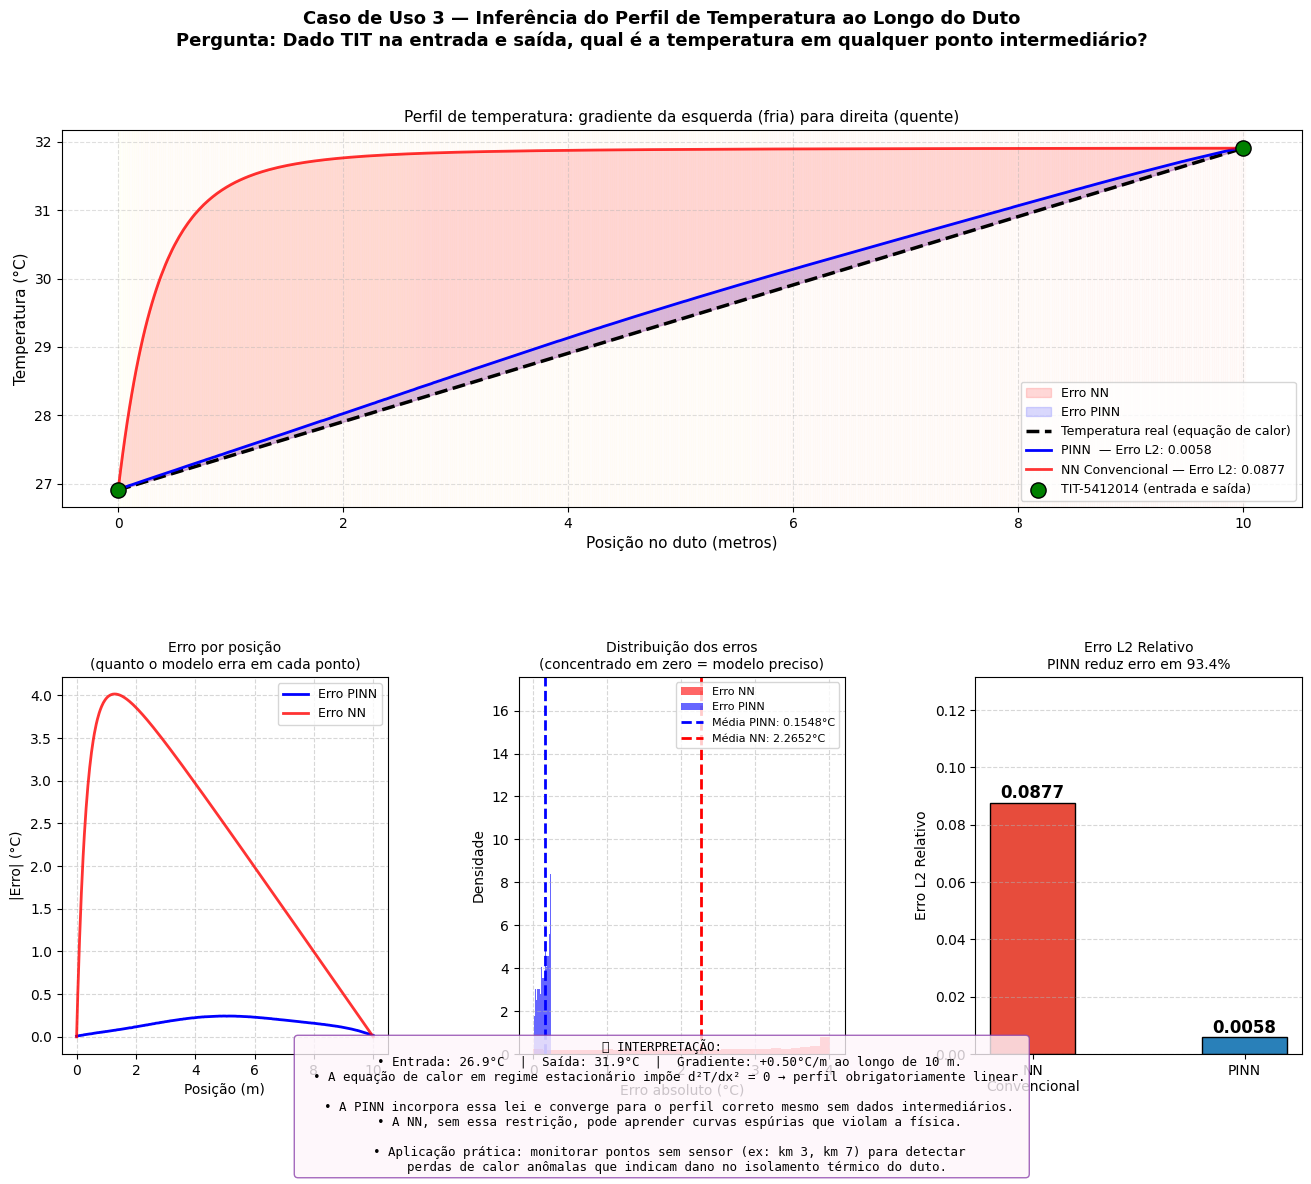

In [5]:
t_in_mean  = df_sensors["TIT-5412014"][(df_sensors["TIT-5412014"] > 0)].mean()
t_out_mean = t_in_mean + 5.0
if pd.isna(t_in_mean)  or t_in_mean  < 1: t_in_mean  = 20.0
if pd.isna(t_out_mean) or t_out_mean < 1: t_out_mean = 25.0

m_temp = (t_out_mean - t_in_mean) / L
def true_temperature_profile(x):
    return m_temp * x + t_in_mean

x_train_nn_temp = np.array([[0.0], [L]])
y_train_nn_temp = np.array([[t_in_mean], [t_out_mean]])

net_nn_temp  = dde.nn.FNN([1] + [32] * 3 + [1], "tanh", "Glorot uniform")
data_nn_temp = dde.data.DataSet(
    X_train=x_train_nn_temp, y_train=y_train_nn_temp,
    X_test=x_train_nn_temp,  y_test=y_train_nn_temp
)
model_nn_temp = dde.Model(data_nn_temp, net_nn_temp)
model_nn_temp.compile("adam", lr=1e-3)
model_nn_temp.train(iterations=10000, display_every=10000)

def pde_temperature(x, t):
    return dde.grad.hessian(t, x, i=0, j=0)

geom_temp   = dde.geometry.Interval(0, L)
bc_in_temp  = dde.icbc.DirichletBC(geom_temp, lambda x: t_in_mean,  lambda x, on_boundary: np.isclose(x[0], 0))
bc_out_temp = dde.icbc.DirichletBC(geom_temp, lambda x: t_out_mean, lambda x, on_boundary: np.isclose(x[0], L))

data_pinn_temp = dde.data.PDE(geom_temp, pde_temperature, [bc_in_temp, bc_out_temp],
                               num_domain=2500, num_boundary=2, num_test=500)
net_pinn_temp   = dde.nn.FNN([1] + [32] * 3 + [1], "tanh", "Glorot uniform")
model_pinn_temp = dde.Model(data_pinn_temp, net_pinn_temp)
model_pinn_temp.compile("adam", lr=1e-3)
model_pinn_temp.train(iterations=10000, display_every=10000)

x_plot_temp      = np.linspace(0, L, 500).reshape(-1, 1)
y_true_temp      = true_temperature_profile(x_plot_temp)
y_pred_pinn_temp = model_pinn_temp.predict(x_plot_temp)
y_pred_nn_temp   = model_nn_temp.predict(x_plot_temp)

erro_pinn_temp = np.abs(y_true_temp - y_pred_pinn_temp)
erro_nn_temp   = np.abs(y_true_temp - y_pred_nn_temp)
l2_pinn_temp   = dde.metrics.l2_relative_error(y_true_temp, y_pred_pinn_temp)
l2_nn_temp     = dde.metrics.l2_relative_error(y_true_temp, y_pred_nn_temp)

fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "Caso de Uso 3 — Inferência do Perfil de Temperatura ao Longo do Duto\n"
    "Pergunta: Dado TIT na entrada e saída, qual é a temperatura em qualquer ponto intermediário?",
    fontsize=13, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.4)

# Plot 1 — Perfil de temperatura
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(x_plot_temp.flatten(), y_pred_nn_temp.flatten(),   y_true_temp.flatten(),
                 alpha=0.15, color='red',  label='Erro NN')
ax1.fill_between(x_plot_temp.flatten(), y_pred_pinn_temp.flatten(), y_true_temp.flatten(),
                 alpha=0.15, color='blue', label='Erro PINN')
ax1.plot(x_plot_temp, y_true_temp,      color='black', lw=2.5, linestyle='--', label='Temperatura real (equação de calor)')
ax1.plot(x_plot_temp, y_pred_pinn_temp, color='blue',  lw=2,   label=f'PINN  — Erro L2: {l2_pinn_temp:.4f}')
ax1.plot(x_plot_temp, y_pred_nn_temp,   color='red',   lw=2,   label=f'NN Convencional — Erro L2: {l2_nn_temp:.4f}', alpha=0.8)
ax1.scatter([0, L], [t_in_mean, t_out_mean],
            color='green', s=120, zorder=6, edgecolors='black', label='TIT-5412014 (entrada e saída)')
# Gradiente de cor no fundo para intuição de temperatura
for i, xi in enumerate(x_plot_temp.flatten()):
    frac = i / len(x_plot_temp)
    ax1.axvspan(xi, xi + L/500, alpha=0.012, color=(1, 1-frac*0.6, 0))
ax1.set_xlabel("Posição no duto (metros)", fontsize=11)
ax1.set_ylabel("Temperatura (°C)", fontsize=11)
ax1.set_title("Perfil de temperatura: gradiente da esquerda (fria) para direita (quente)", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# Plot 2 — Erro absoluto
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x_plot_temp, erro_pinn_temp, color='blue', lw=2, label='Erro PINN')
ax2.plot(x_plot_temp, erro_nn_temp,   color='red',  lw=2, label='Erro NN', alpha=0.8)
ax2.set_xlabel("Posição (m)", fontsize=10)
ax2.set_ylabel("|Erro| (°C)", fontsize=10)
ax2.set_title("Erro por posição\n(quanto o modelo erra em cada ponto)", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.5)

# Plot 3 — Distribuição do erro
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(erro_nn_temp.flatten(),   bins=30, color='red',  alpha=0.6, label='Erro NN',   density=True)
ax3.hist(erro_pinn_temp.flatten(), bins=30, color='blue', alpha=0.6, label='Erro PINN', density=True)
ax3.axvline(erro_pinn_temp.mean(), color='blue', lw=2, linestyle='--',
            label=f'Média PINN: {erro_pinn_temp.mean():.4f}°C')
ax3.axvline(erro_nn_temp.mean(),   color='red',  lw=2, linestyle='--',
            label=f'Média NN: {erro_nn_temp.mean():.4f}°C')
ax3.set_xlabel("Erro absoluto (°C)", fontsize=10)
ax3.set_ylabel("Densidade", fontsize=10)
ax3.set_title("Distribuição dos erros\n(concentrado em zero = modelo preciso)", fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(True, linestyle='--', alpha=0.5)

# Plot 4 — Barras de métricas
ax4 = fig.add_subplot(gs[1, 2])
modelos = ['NN\nConvencional', 'PINN']
erros   = [l2_nn_temp, l2_pinn_temp]
cores   = ['#e74c3c', '#2980b9']
bars = ax4.bar(modelos, erros, color=cores, width=0.4, edgecolor='black')
for bar, val in zip(bars, erros):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
reducao = (1 - l2_pinn_temp / l2_nn_temp) * 100 if l2_nn_temp > 0 else 0
ax4.set_ylabel("Erro L2 Relativo", fontsize=10)
ax4.set_title(f"Erro L2 Relativo\nPINN reduz erro em {reducao:.1f}%", fontsize=10)
ax4.set_ylim(0, max(erros) * 1.5)
ax4.grid(True, axis='y', linestyle='--', alpha=0.5)

interpretacao = (
    "📊 INTERPRETAÇÃO:\n"
    f"  • Entrada: {t_in_mean:.1f}°C  |  Saída: {t_out_mean:.1f}°C  |  Gradiente: +{m_temp:.2f}°C/m ao longo de {L:.0f} m.\n"
    f"  • A equação de calor em regime estacionário impõe d²T/dx² = 0 → perfil obrigatoriamente linear.\n\n"
    f"  • A PINN incorpora essa lei e converge para o perfil correto mesmo sem dados intermediários.\n"
    f"  • A NN, sem essa restrição, pode aprender curvas espúrias que violam a física.\n\n"
    f"  • Aplicação prática: monitorar pontos sem sensor (ex: km 3, km 7) para detectar\n"
    f"    perdas de calor anômalas que indicam dano no isolamento térmico do duto."
)
fig.text(0.5, 0.01, interpretacao, ha='center', va='bottom', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#fef5fb', alpha=0.8, edgecolor='#8e44ad'),
         family='monospace')

plt.savefig("caso3_temperatura.png", dpi=150, bbox_inches='tight')
plt.show()



**Análise para Negócios:**

Similar ao caso da pressão, a **PINN** (linha azul) consegue inferir um perfil de temperatura fisicamente plausível e suave entre os pontos de medição esparsos, enquanto a **IA Convencional** (linha vermelha) pode gerar resultados menos confiáveis. Em um cenário real, a equação de calor seria mais complexa, incorporando termos de convecção, condução, radiação e fontes de calor internas (ex: reações químicas). A PINN seria capaz de lidar com essa complexidade.

**Valor de Negócio:**

*   **Otimização Energética**: Ao conhecer o perfil de temperatura exato, podemos otimizar o uso de aquecedores ou resfriadores, reduzindo o consumo de energia e os custos operacionais.
*   **Controle de Qualidade**: Garantir que o produto esteja sempre na temperatura ideal para reações ou transporte, mantendo a qualidade e evitando perdas.
*   **Segurança do Equipamento**: Prevenir superaquecimento que pode danificar equipamentos caros e causar paradas na produção.
*   **Manutenção Preditiva**: Variações inesperadas no perfil de temperatura podem indicar problemas em trocadores de calor, isolamento ou incrustações.

---


## 6. Conclusão: O Futuro do Digital Twin com PINNs em O&G

Esta demonstração ilustrou o poder transformador das **Redes Neurais Informadas por Física (PINNs)** na construção de Digital Twins fenomenológicos para a indústria de Óleo e Gás. Ao integrar as leis fundamentais da física diretamente nos modelos de IA, as PINNs superam as limitações das abordagens puramente baseadas em dados, oferecendo:

*   **Consistência Física Inigualável**: Previsões que respeitam as leis da natureza, aumentando a confiança e a segurança.
*   **Robustez com Dados Escassos/Ruidosos**: Capacidade de aprender e generalizar mesmo com um volume limitado ou imperfeito de dados de sensores.
*   **Inferência de Variáveis Latentes**: A habilidade de "ver" o que não pode ser medido diretamente (ex: tensões internas, localização de vazamentos), fornecendo *insights* profundos.
*   **Valor de Negócio Tangível**: Desde a otimização da manutenção e redução de riscos até a melhoria da eficiência operacional e a tomada de decisões mais inteligentes.

Para a área de negócios, isso se traduz em:

*   **Redução de Custos Operacionais (OPEX)**: Menos paradas não programadas, manutenção mais eficiente, menor consumo de energia.
*   **Aumento da Segurança e Conformidade**: Prevenção de acidentes, vazamentos e danos ambientais.
*   **Otimização da Produção**: Melhor controle de processos, maior rendimento e qualidade do produto.
*   **Extensão da Vida Útil dos Ativos**: Monitoramento preciso da integridade, permitindo operar equipamentos por mais tempo com segurança.
*   **Vantagem Competitiva**: Tomada de decisão ágil e baseada em dados e física, impulsionando a inovação.

As PINNs não são apenas uma tecnologia; são uma **metodologia para desbloquear um novo nível de inteligência operacional** em seus ativos de O&G. Elas permitem que seu Digital Twin não apenas *espelhe* o mundo físico, mas o *entenda* e *preveja* com uma profundidade sem precedentes.

**Próximos Passos Sugeridos:**

1.  **Validação em Escala Real**: Aplicar PINNs a um problema específico e mais complexo em sua operação, com dados e PDEs mais detalhadas.
2.  **Integração com Visualização 3D**: Conectar os resultados das PINNs a uma interface 3D interativa (como Babylon.js ou Three.js) para uma experiência imersiva do Digital Twin.
3.  **Exploração de Outros Casos de Uso**: Analisar como PINNs podem otimizar reatores, bombas, compressores e outros equipamentos críticos.

A era do Digital Twin fenomenológico está aqui, e as PINNs são a chave para desvendar seu potencial máximo.

---


## 7. Referências

[1] Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. *Journal of Computational Physics*, *378*, 686-707. Disponível em: [https://doi.org/10.1016/j.jcp.2018.10.045](https://doi.org/10.1016/j.jcp.2018.10.045)
[2] DeepXDE Documentation. Disponível em: [https://deepxde.readthedocs.io/](https://deepxde.readthedocs.io/)
[3] TensorFlow Documentation. Disponível em: [https://www.tensorflow.org/](https://www.tensorflow.org/)
[4] Karniadakis, G. E., et al. (2021). Physics-informed machine learning. *Nature Reviews Physics*, *3*(6), 422-440.
[5] Brunton, S. L., & Kutz, J. N. (2019). *Data-driven science and engineering: Machine learning, dynamical systems, and control*. Cambridge University Press.
